In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Import custom utilities
import sys
sys.path.append('utils')
from utils.h5_data_loader import H5DataLoader

# Set up plotting
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 10
sns.set_palette("husl")

# Configuration
H5_FILE_PATH = r"D:\Data\ScienceCorp\trials_aligned.h5"  # Update this path if needed
SPIKE_CHANNELS = [0, 1, 2, 3, 6, 32, 39, 40, 41, 42, 46, 49, 53, 67, 68, 73, 74, 75, 76, 77, 84]
SAMPLING_RATE = 30000  # Hz
BIN_SIZE = 0.05  # seconds (50 ms bins)
PRE_STIMULUS_TIME = 1.0  # seconds before stimulus
POST_STIMULUS_TIME = 3.0  # seconds after stimulus

print("✅ Libraries imported successfully!")
print(f"📊 Configuration:")
print(f"   - H5 file: {H5_FILE_PATH}")
print(f"   - Spike channels: {len(SPIKE_CHANNELS)} channels")
print(f"   - Bin size: {BIN_SIZE*1000:.0f} ms")
print(f"   - Time window: -{PRE_STIMULUS_TIME}s to +{POST_STIMULUS_TIME}s")


✅ Libraries imported successfully!
📊 Configuration:
   - H5 file: D:\Data\ScienceCorp\trials_aligned.h5
   - Spike channels: 21 channels
   - Bin size: 50 ms
   - Time window: -1.0s to +3.0s


In [2]:
# Load H5 file and get trial information
print("📊 Loading H5 file and trial information...")

# Check if H5 file exists
if not Path(H5_FILE_PATH).exists():
    print(f"❌ H5 file not found: {H5_FILE_PATH}")
    print("Please update H5_FILE_PATH to point to your integrated H5 file")
else:
    # Create H5 data loader
    h5_loader = H5DataLoader(H5_FILE_PATH)
    
    # Get trial information
    trial_info_df = h5_loader.get_trial_info()
    print(f"✅ Trial info loaded for {len(trial_info_df)} trials")
    
    # Filter for WIN trials only
    win_trials = trial_info_df[trial_info_df['outcome'] == 'win'].copy()
    print(f"🏆 WIN trials: {len(win_trials)} out of {len(trial_info_df)} total trials")
    
    # Group by target
    target_groups = win_trials.groupby('target_index')
    print(f"\n🎯 WIN trials by target:")
    for target_idx, group in target_groups:
        print(f"   Target {target_idx}: {len(group)} trials")
    
    # Show sample of trial info
    print(f"\n📋 Sample WIN trial info:")
    print(win_trials[['trial_number', 'target_index', 'outcome', 'duration']].head())


📊 Loading H5 file and trial information...
✅ Trial info loaded for 140 trials
🏆 WIN trials: 127 out of 140 total trials

🎯 WIN trials by target:
   Target 0: 20 trials
   Target 1: 14 trials
   Target 2: 14 trials
   Target 3: 13 trials
   Target 4: 17 trials
   Target 5: 15 trials
   Target 6: 18 trials
   Target 7: 16 trials

📋 Sample WIN trial info:
   trial_number  target_index outcome  duration
1             2             4     win  2.705604
2             3             7     win  3.400151
3             4             7     win  3.059571
4             5             5     win  4.481940
5             6             1     win  1.727066


In [3]:
def compute_psth_for_trial(neural_data, channels, sampling_rate, bin_size, pre_time, post_time):
    """
    Compute PSTH for a single trial using improved bandpass filtering and power computation.
    
    Parameters:
    -----------
    neural_data : np.ndarray
        Neural data array (channels x time)
    channels : list
        List of channel indices to use
    sampling_rate : int
        Sampling rate in Hz
    bin_size : float
        Bin size in seconds
    pre_time : float
        Pre-stimulus time in seconds
    post_time : float
        Post-stimulus time in seconds
        
    Returns:
    --------
    tuple
        (psth_data, time_axis) - PSTH data and time axis
    """
    from scipy import signal
    
    # Bandpass filter for spike activity (300-3000 Hz)
    def bandpass_filter(data, low_freq, high_freq, fs):
        nyquist = fs / 2
        low = low_freq / nyquist
        high = high_freq / nyquist
        b, a = signal.butter(4, [low, high], btype='band')
        return signal.filtfilt(b, a, data)
    
    # Filter the data first to isolate spike activity
    filtered_data = np.zeros_like(neural_data)
    valid_channels = [ch for ch in channels if ch < neural_data.shape[0]]
    
    for ch in valid_channels:
        try:
            filtered_data[ch, :] = bandpass_filter(neural_data[ch, :], 300, 3000, sampling_rate)
        except:
            filtered_data[ch, :] = neural_data[ch, :]
    
    # Use the middle of the trial as stimulus onset
    stimulus_onset_sample = neural_data.shape[1] // 2
    
    # Calculate sample indices for our time window
    pre_samples = int(pre_time * sampling_rate)
    post_samples = int(post_time * sampling_rate)
    
    start_sample = max(0, stimulus_onset_sample - pre_samples)
    end_sample = min(neural_data.shape[1], stimulus_onset_sample + post_samples)
    
    # Extract the relevant time window
    if start_sample >= end_sample:
        return None, None
    
    window_data = filtered_data[:, start_sample:end_sample]
    
    # Compute binned activity for each channel
    samples_per_bin = int(bin_size * sampling_rate)
    n_samples = window_data.shape[1]
    actual_n_bins = n_samples // samples_per_bin
    
    if actual_n_bins == 0:
        return None, None
    
    # Reshape data for binning
    trimmed_samples = actual_n_bins * samples_per_bin
    trimmed_data = window_data[:, :trimmed_samples]
    
    # Compute power (squared amplitude) in each bin for each channel
    binned_data = trimmed_data.reshape(trimmed_data.shape[0], actual_n_bins, samples_per_bin)
    psth_data = np.mean(binned_data**2, axis=2)  # Power in each bin
    
    if len(valid_channels) == 0:
        return None, None
    
    # Average across specified channels
    averaged_psth = np.mean(psth_data[valid_channels, :], axis=0)
    
    # Create time axis
    time_axis = np.linspace(-pre_time, post_time, actual_n_bins)
    
    return averaged_psth, time_axis

print("✅ Improved PSTH computation function defined")


✅ Improved PSTH computation function defined


In [4]:
# Compute improved PSTH for each target
print("🧠 Computing improved PSTH for each target...")

target_psths = {}

for target_idx, group in target_groups:
    print(f"\n🎯 Processing target {target_idx} ({len(group)} trials)...")
    
    trial_psths = []
    trial_times = []
    
    for _, trial_info in group.iterrows():
        trial_number = trial_info['trial_number']
        
        try:
            # Load trial data
            trial_data = h5_loader.load_trial_data(trial_number)
            
            if trial_data['neural_data'] is None:
                print(f"   ⚠️ No neural data for trial {trial_number}")
                continue
            
            # Compute improved PSTH for this trial
            psth, time_axis = compute_psth_for_trial(
                trial_data['neural_data'], 
                SPIKE_CHANNELS, 
                SAMPLING_RATE, 
                BIN_SIZE, 
                PRE_STIMULUS_TIME, 
                POST_STIMULUS_TIME
            )
            
            if psth is not None:
                trial_psths.append(psth)
                trial_times.append(time_axis)
            
        except Exception as e:
            print(f"   ❌ Error processing trial {trial_number}: {e}")
            continue
    
    if len(trial_psths) > 0:
        # Average across trials
        # Find the minimum length to handle any size differences
        min_length = min(len(psth) for psth in trial_psths)
        
        # Truncate all PSTHs to the same length
        truncated_psths = [psth[:min_length] for psth in trial_psths]
        truncated_times = [time[:min_length] for time in trial_times]
        
        # Average across trials
        avg_psth = np.mean(truncated_psths, axis=0)
        sem_psth = np.std(truncated_psths, axis=0) / np.sqrt(len(truncated_psths))
        avg_time = truncated_times[0]  # Time axis should be the same for all
        
        # Calculate coefficient of variation for quality assessment
        cv = np.std(avg_psth) / np.mean(avg_psth) if np.mean(avg_psth) > 0 else 0
        
        target_psths[target_idx] = {
            'psth': avg_psth,
            'sem': sem_psth,
            'time': avg_time,
            'n_trials': len(truncated_psths),
            'cv': cv
        }
        
        print(f"   ✅ Target {target_idx}: {len(truncated_psths)} trials processed, CV={cv:.3f}")
    else:
        print(f"   ❌ No valid trials for target {target_idx}")

print(f"\n✅ Improved PSTH computation complete for {len(target_psths)} targets")
print(f"📊 Using bandpass filtering (300-3000 Hz) and power computation")


🧠 Computing improved PSTH for each target...

🎯 Processing target 0 (20 trials)...
   ✅ Target 0: 20 trials processed, CV=0.036

🎯 Processing target 1 (14 trials)...
   ✅ Target 1: 14 trials processed, CV=0.075

🎯 Processing target 2 (14 trials)...
   ✅ Target 2: 14 trials processed, CV=0.062

🎯 Processing target 3 (13 trials)...
   ✅ Target 3: 13 trials processed, CV=0.054

🎯 Processing target 4 (17 trials)...
   ✅ Target 4: 17 trials processed, CV=0.030

🎯 Processing target 5 (15 trials)...
   ✅ Target 5: 15 trials processed, CV=0.041

🎯 Processing target 6 (18 trials)...
   ✅ Target 6: 18 trials processed, CV=0.033

🎯 Processing target 7 (16 trials)...
   ✅ Target 7: 16 trials processed, CV=0.035

✅ Improved PSTH computation complete for 8 targets
📊 Using bandpass filtering (300-3000 Hz) and power computation


📊 Creating PSTH plots...


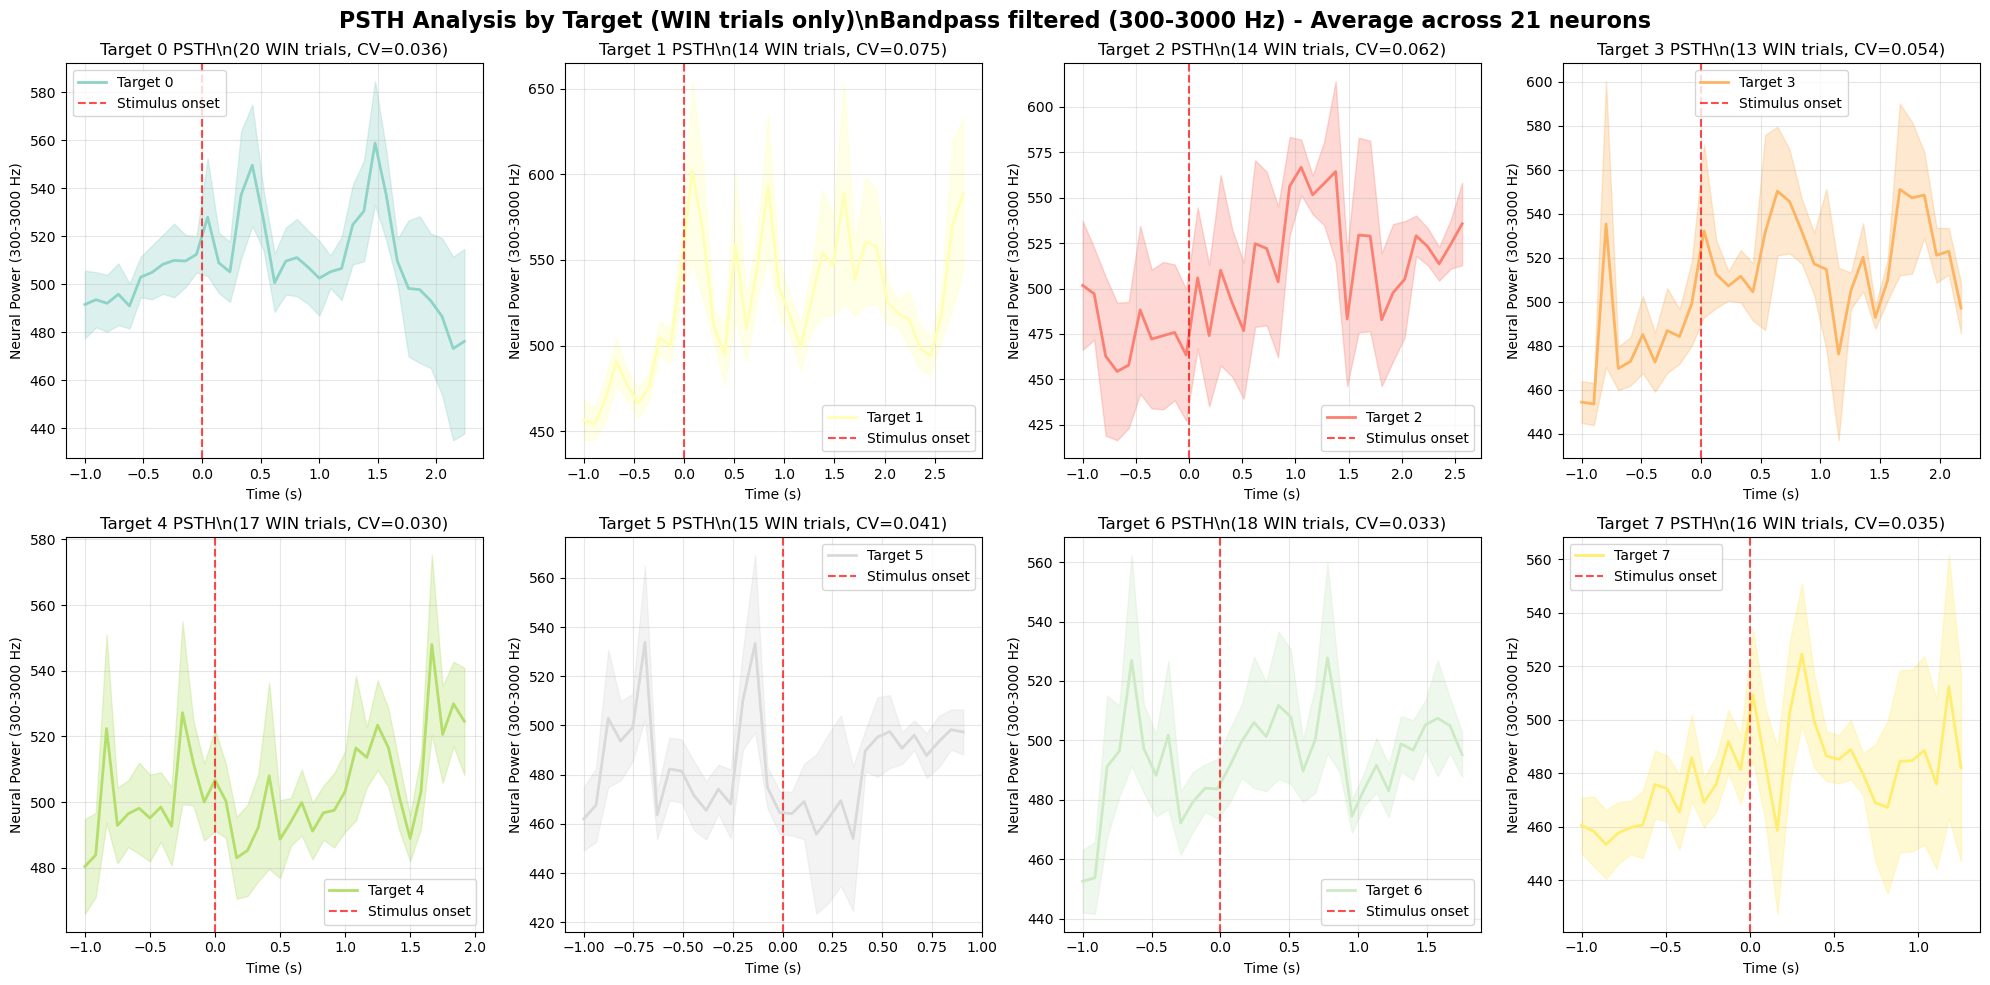

✅ PSTH plots created!


In [5]:
# Create PSTH plots for each target
print("📊 Creating PSTH plots...")

# Create a figure with subplots for each target
n_targets = len(target_psths)
n_cols = 4
n_rows = (n_targets + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
if n_cols == 1:
    axes = axes.reshape(-1, 1)

# Define colors for each target
colors = plt.cm.Set3(np.linspace(0, 1, 8))

plot_idx = 0
for target_idx in sorted(target_psths.keys()):
    row = plot_idx // n_cols
    col = plot_idx % n_cols
    ax = axes[row, col]
    
    data = target_psths[target_idx]
    
    # Plot PSTH with error bars
    ax.plot(data['time'], data['psth'], color=colors[target_idx], linewidth=2, 
            label=f'Target {target_idx}')
    ax.fill_between(data['time'], 
                    data['psth'] - data['sem'], 
                    data['psth'] + data['sem'], 
                    alpha=0.3, color=colors[target_idx])
    
    # Add vertical line at stimulus onset
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Stimulus onset')
    
    # Formatting
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Neural Power (300-3000 Hz)')
    ax.set_title(f'Target {target_idx} PSTH\\n({data["n_trials"]} WIN trials, CV={data["cv"]:.3f})')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plot_idx += 1

# Hide unused subplots
for i in range(plot_idx, n_rows * n_cols):
    row = i // n_cols
    col = i % n_cols
    axes[row, col].set_visible(False)

plt.suptitle('PSTH Analysis by Target (WIN trials only)\\nBandpass filtered (300-3000 Hz) - Average across 21 neurons', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ PSTH plots created!")


📊 Creating summary comparison plot...


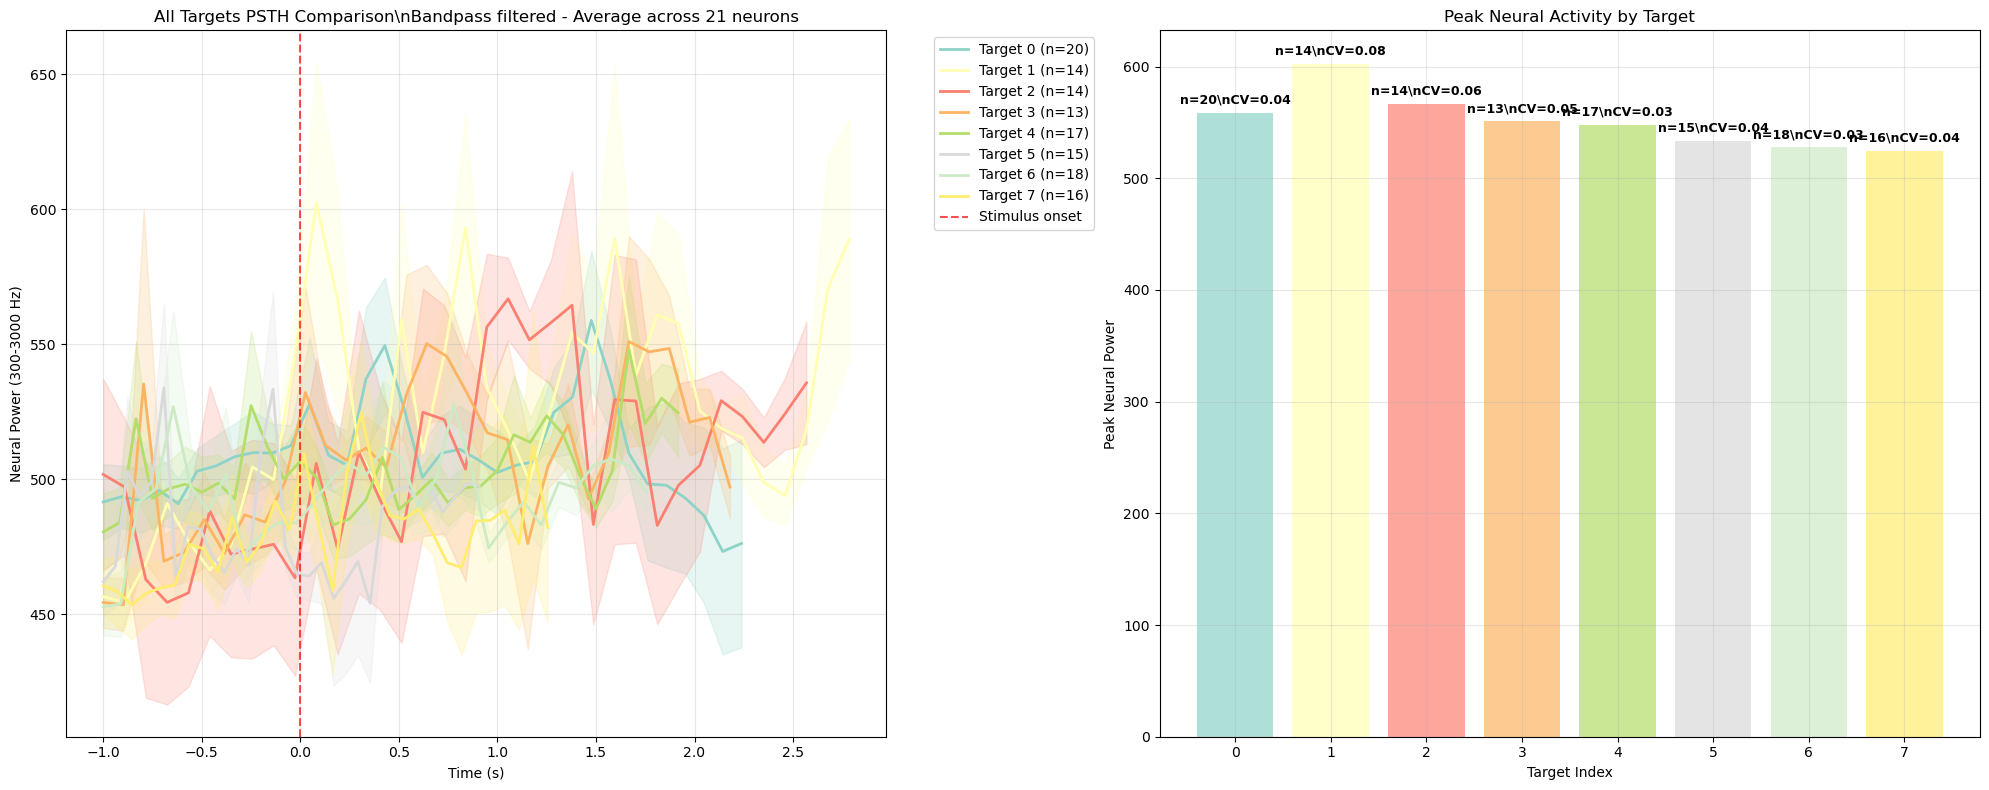

✅ Summary plots created!


In [6]:
# Create a summary plot comparing all targets
print("📊 Creating summary comparison plot...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: All PSTHs overlaid
for target_idx in sorted(target_psths.keys()):
    data = target_psths[target_idx]
    ax1.plot(data['time'], data['psth'], color=colors[target_idx], linewidth=2, 
             label=f'Target {target_idx} (n={data["n_trials"]})')
    ax1.fill_between(data['time'], 
                     data['psth'] - data['sem'], 
                     data['psth'] + data['sem'], 
                     alpha=0.2, color=colors[target_idx])

ax1.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Stimulus onset')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Neural Power (300-3000 Hz)')
ax1.set_title('All Targets PSTH Comparison\\nBandpass filtered - Average across 21 neurons')
ax1.grid(True, alpha=0.3)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 2: Peak activity by target
target_indices = sorted(target_psths.keys())
peak_activities = []
peak_times = []
n_trials = []
cvs = []

for target_idx in target_indices:
    data = target_psths[target_idx]
    peak_idx = np.argmax(data['psth'])
    peak_activities.append(data['psth'][peak_idx])
    peak_times.append(data['time'][peak_idx])
    n_trials.append(data['n_trials'])
    cvs.append(data['cv'])

bars = ax2.bar(target_indices, peak_activities, color=[colors[i] for i in target_indices], alpha=0.7)
ax2.set_xlabel('Target Index')
ax2.set_ylabel('Peak Neural Power')
ax2.set_title('Peak Neural Activity by Target')
ax2.grid(True, alpha=0.3)

# Add trial count and CV labels on bars
for bar, n_trial, cv in zip(bars, n_trials, cvs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01, 
             f'n={n_trial}\\nCV={cv:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("✅ Summary plots created!")


In [7]:
# Print summary statistics
print("📊 IMPROVED PSTH ANALYSIS SUMMARY")
print("=" * 60)

total_trials = sum(data['n_trials'] for data in target_psths.values())
avg_cv = np.mean([data['cv'] for data in target_psths.values()])

print(f"🏆 Method: Bandpass filtered neural power (300-3000 Hz)")
print(f"📊 Total WIN trials analyzed: {total_trials}")
print(f"🎯 Targets analyzed: {len(target_psths)}")
print(f"🧠 Neurons averaged: {len(SPIKE_CHANNELS)}")
print(f"⏱️ Time window: -{PRE_STIMULUS_TIME}s to +{POST_STIMULUS_TIME}s")
print(f"📏 Bin size: {BIN_SIZE*1000:.0f} ms")
print(f"📈 Average coefficient of variation: {avg_cv:.3f}")

print(f"\n🎯 Target-wise Statistics:")
for target_idx in sorted(target_psths.keys()):
    data = target_psths[target_idx]
    peak_idx = np.argmax(data['psth'])
    peak_activity = data['psth'][peak_idx]
    peak_time = data['time'][peak_idx]
    baseline_activity = np.mean(data['psth'][data['time'] < -0.5])  # Baseline before stimulus
    
    print(f"   Target {target_idx}: {data['n_trials']} trials")
    print(f"     Peak power: {peak_activity:.3f} at {peak_time:.2f}s")
    print(f"     Baseline power: {baseline_activity:.3f}")
    if baseline_activity > 0:
        print(f"     Peak/baseline ratio: {peak_activity/baseline_activity:.2f}")
    print(f"     Coefficient of variation: {data['cv']:.3f}")
    print()

print("✅ Improved PSTH analysis complete!")
print("📈 Higher CV values indicate more dynamic neural responses")


📊 IMPROVED PSTH ANALYSIS SUMMARY
🏆 Method: Bandpass filtered neural power (300-3000 Hz)
📊 Total WIN trials analyzed: 127
🎯 Targets analyzed: 8
🧠 Neurons averaged: 21
⏱️ Time window: -1.0s to +3.0s
📏 Bin size: 50 ms
📈 Average coefficient of variation: 0.046

🎯 Target-wise Statistics:
   Target 0: 20 trials
     Peak power: 558.790 at 1.48s
     Baseline power: 494.447
     Peak/baseline ratio: 1.13
     Coefficient of variation: 0.036

   Target 1: 14 trials
     Peak power: 602.371 at 0.08s
     Baseline power: 469.506
     Peak/baseline ratio: 1.28
     Coefficient of variation: 0.075

   Target 2: 14 trials
     Peak power: 566.821 at 1.05s
     Baseline power: 474.770
     Peak/baseline ratio: 1.19
     Coefficient of variation: 0.062

   Target 3: 13 trials
     Peak power: 550.964 at 1.67s
     Baseline power: 477.078
     Peak/baseline ratio: 1.15
     Coefficient of variation: 0.054

   Target 4: 17 trials
     Peak power: 547.975 at 1.67s
     Baseline power: 495.696
     Peak/

🔬 DEBUG: Testing alternative PSTH computation methods...
🧪 Method 1: High-frequency power analysis...
   Filtered data range: -481.000 to 246.000
🧪 Method 2: Spike detection...
   Channel 0: 229 spikes detected
   Channel 1: 510 spikes detected
   Channel 2: 522 spikes detected
   Channel 3: 334 spikes detected
   Channel 6: 136 spikes detected
🧪 Method 3: Improved PSTH with spike-band filtering...
   Power PSTH range: 0.000 to 1737.433


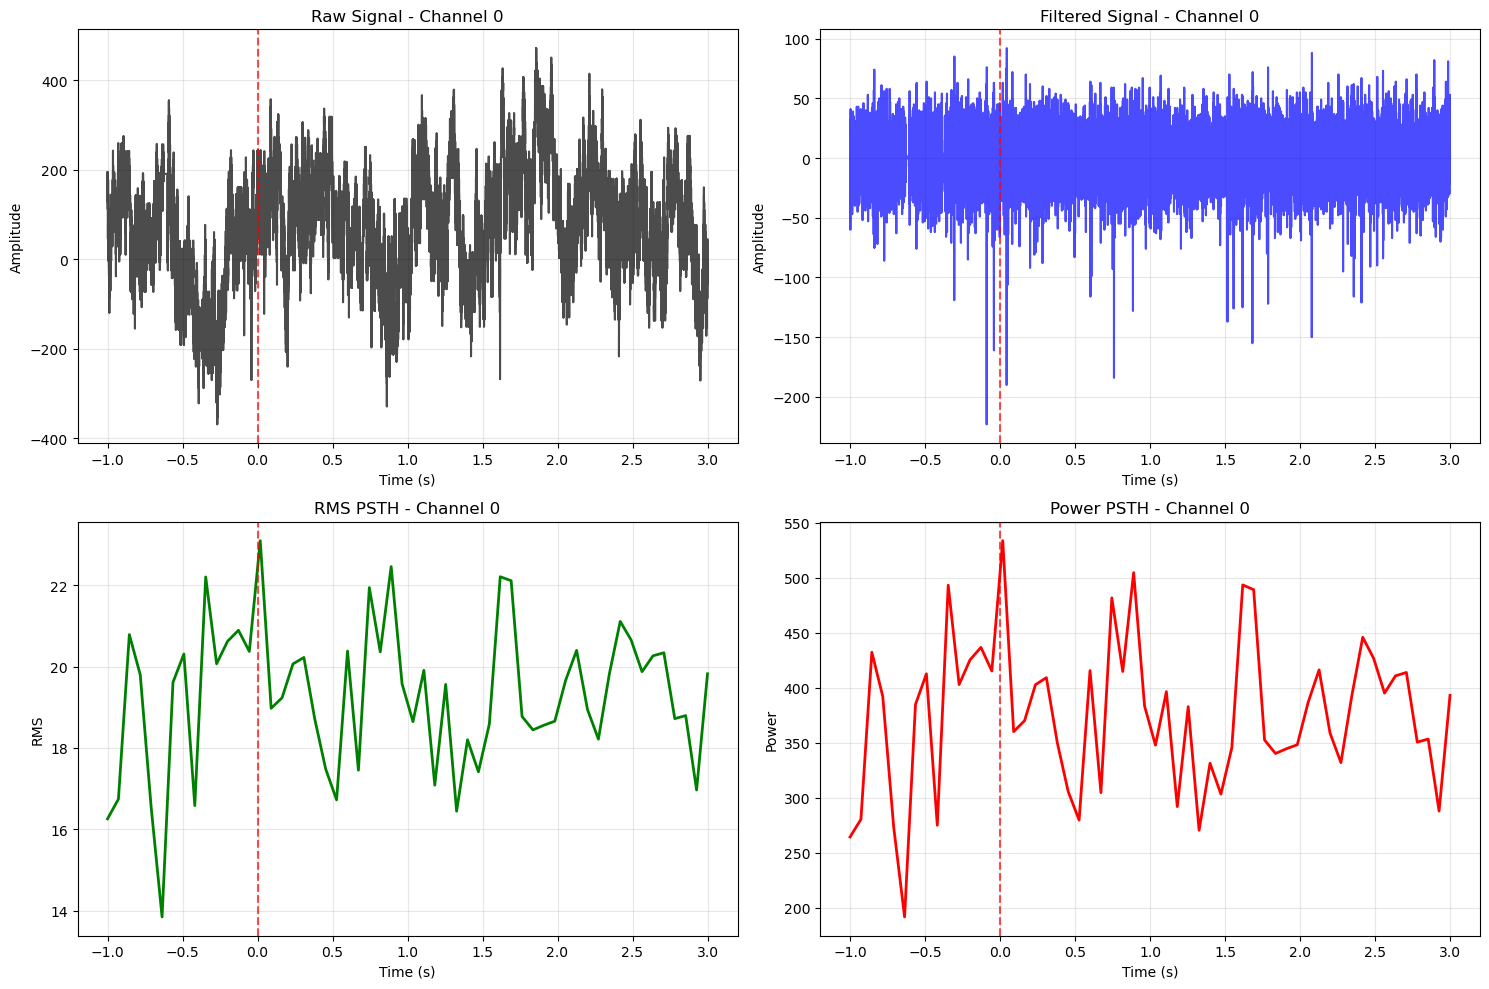


📊 Power PSTH average:
   Range: 370.841 to 585.705
   Mean: 509.135
   Std: 39.777


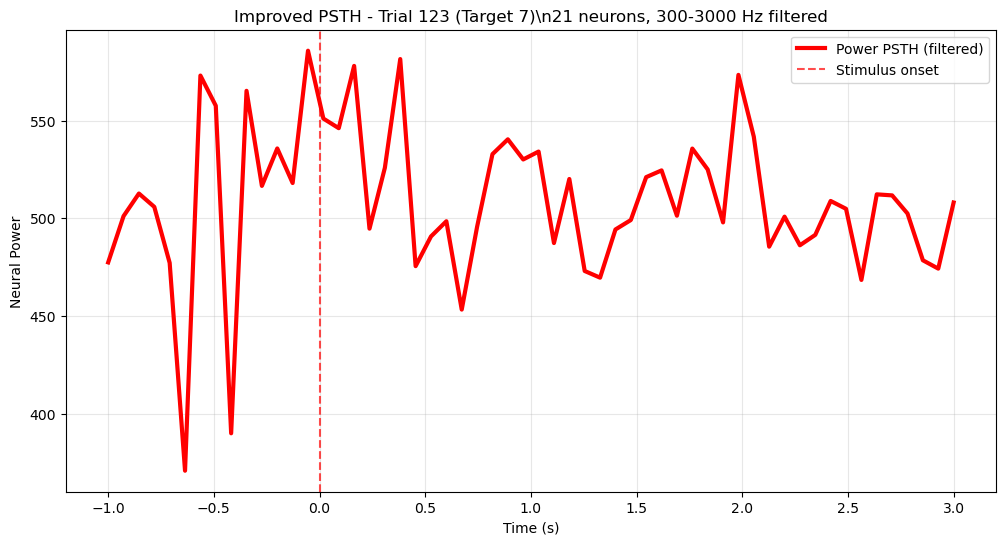

🧪 Method 4: Spike rate PSTH...
   Spike rate PSTH range: 46.667 to 158.095 Hz
   Mean firing rate: 89.320 Hz


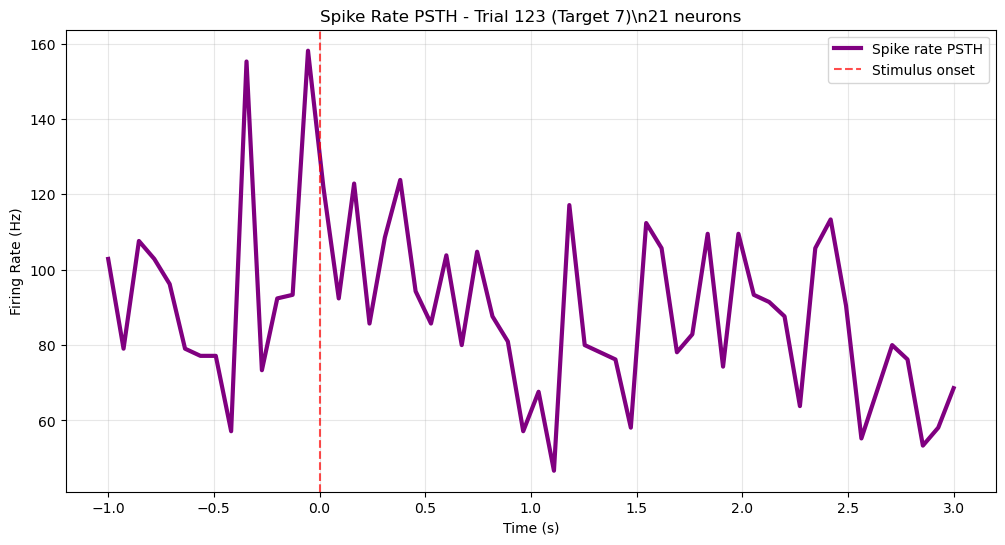


📊 Method comparison:
   RMS PSTH coefficient of variation: 0.038
   Power PSTH coefficient of variation: 0.078
   Spike rate PSTH coefficient of variation: 0.258


In [8]:
# DEBUG: Alternative PSTH computation methods
print("🔬 DEBUG: Testing alternative PSTH computation methods...")

# Let's try different approaches to compute meaningful neural activity
if 'trial_data' in locals():
    neural_data = trial_data['neural_data']
    valid_spike_channels = [ch for ch in SPIKE_CHANNELS if ch < neural_data.shape[0]]
    
    # Method 1: High-frequency power (instead of RMS)
    print("🧪 Method 1: High-frequency power analysis...")
    
    from scipy import signal
    
    # Apply bandpass filter for spike band
    def bandpass_filter(data, low_freq, high_freq, fs):
        nyquist = fs / 2
        low = low_freq / nyquist
        high = high_freq / nyquist
        b, a = signal.butter(4, [low, high], btype='band')
        return signal.filtfilt(b, a, data)
    
    # Filter the neural data
    filtered_data = np.zeros_like(neural_data)
    for ch in valid_spike_channels:
        try:
            filtered_data[ch, :] = bandpass_filter(neural_data[ch, :], 300, 3000, SAMPLING_RATE)
        except:
            filtered_data[ch, :] = neural_data[ch, :]
    
    print(f"   Filtered data range: {filtered_data.min():.3f} to {filtered_data.max():.3f}")
    
    # Method 2: Threshold crossings (spike detection)
    print("🧪 Method 2: Spike detection...")
    
    def detect_spikes(data, threshold_factor=-4):
        """Simple spike detection using threshold crossings"""
        threshold = threshold_factor * np.std(data)
        spikes = np.where(data < threshold)[0]  # Negative threshold
        return spikes
    
    # Count spikes in each channel
    spike_counts = {}
    for ch in valid_spike_channels[:5]:  # First 5 channels
        spikes = detect_spikes(filtered_data[ch, :])
        spike_counts[ch] = len(spikes)
        print(f"   Channel {ch}: {len(spikes)} spikes detected")
    
    # Method 3: Improved PSTH with spike-band filtering
    print("🧪 Method 3: Improved PSTH with spike-band filtering...")
    
    # Use filtered data for PSTH
    stimulus_onset_sample = neural_data.shape[1] // 2
    pre_samples = int(PRE_STIMULUS_TIME * SAMPLING_RATE)
    post_samples = int(POST_STIMULUS_TIME * SAMPLING_RATE)
    
    start_sample = max(0, stimulus_onset_sample - pre_samples)
    end_sample = min(neural_data.shape[1], stimulus_onset_sample + post_samples)
    
    window_data = filtered_data[:, start_sample:end_sample]
    
    # Compute binned activity using squared filtered signal (power)
    samples_per_bin = int(BIN_SIZE * SAMPLING_RATE)
    n_samples = window_data.shape[1]
    actual_n_bins = n_samples // samples_per_bin
    
    if actual_n_bins > 0:
        trimmed_samples = actual_n_bins * samples_per_bin
        trimmed_data = window_data[:, :trimmed_samples]
        
        # Compute power in each bin
        binned_data = trimmed_data.reshape(trimmed_data.shape[0], actual_n_bins, samples_per_bin)
        power_psth = np.mean(binned_data**2, axis=2)  # Power instead of RMS
        
        print(f"   Power PSTH range: {power_psth.min():.3f} to {power_psth.max():.3f}")
        
        # Create time axis
        time_axis = np.linspace(-PRE_STIMULUS_TIME, POST_STIMULUS_TIME, actual_n_bins)
        
        # Plot comparison of methods
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Choose one channel to demonstrate
        demo_ch = valid_spike_channels[0]
        
        # Plot 1: Raw signal
        ax = axes[0, 0]
        time_raw = np.linspace(-PRE_STIMULUS_TIME, POST_STIMULUS_TIME, window_data.shape[1])
        ax.plot(time_raw, neural_data[demo_ch, start_sample:end_sample], 'k-', alpha=0.7)
        ax.axvline(x=0, color='red', linestyle='--', alpha=0.7)
        ax.set_title(f'Raw Signal - Channel {demo_ch}')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Amplitude')
        ax.grid(True, alpha=0.3)
        
        # Plot 2: Filtered signal
        ax = axes[0, 1]
        ax.plot(time_raw, window_data[demo_ch, :], 'b-', alpha=0.7)
        ax.axvline(x=0, color='red', linestyle='--', alpha=0.7)
        ax.set_title(f'Filtered Signal - Channel {demo_ch}')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Amplitude')
        ax.grid(True, alpha=0.3)
        
        # Plot 3: RMS PSTH
        ax = axes[1, 0]
        rms_psth = np.sqrt(np.mean(binned_data**2, axis=2))
        ax.plot(time_axis, rms_psth[demo_ch, :], 'g-', linewidth=2)
        ax.axvline(x=0, color='red', linestyle='--', alpha=0.7)
        ax.set_title(f'RMS PSTH - Channel {demo_ch}')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('RMS')
        ax.grid(True, alpha=0.3)
        
        # Plot 4: Power PSTH
        ax = axes[1, 1]
        ax.plot(time_axis, power_psth[demo_ch, :], 'r-', linewidth=2)
        ax.axvline(x=0, color='red', linestyle='--', alpha=0.7)
        ax.set_title(f'Power PSTH - Channel {demo_ch}')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Power')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Average across channels for power method
        avg_power_psth = np.mean(power_psth[valid_spike_channels, :], axis=0)
        
        print(f"\n📊 Power PSTH average:")
        print(f"   Range: {avg_power_psth.min():.3f} to {avg_power_psth.max():.3f}")
        print(f"   Mean: {avg_power_psth.mean():.3f}")
        print(f"   Std: {avg_power_psth.std():.3f}")
        
        # Plot the improved average
        plt.figure(figsize=(12, 6))
        plt.plot(time_axis, avg_power_psth, 'r-', linewidth=3, label='Power PSTH (filtered)')
        plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Stimulus onset')
        plt.xlabel('Time (s)')
        plt.ylabel('Neural Power')
        plt.title(f'Improved PSTH - Trial {trial_number} (Target {target_idx})\\n{len(valid_spike_channels)} neurons, 300-3000 Hz filtered')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()
        
        # Method 4: Spike rate PSTH
        print("🧪 Method 4: Spike rate PSTH...")
        
        # Detect spikes in the time window
        spike_rate_psth = np.zeros((len(valid_spike_channels), actual_n_bins))
        
        for i, ch in enumerate(valid_spike_channels):
            ch_data = window_data[ch, :trimmed_samples]
            threshold = -4 * np.std(ch_data)
            
            # Find spikes
            spikes = np.where(ch_data < threshold)[0]
            
            # Bin spikes
            for bin_idx in range(actual_n_bins):
                bin_start = bin_idx * samples_per_bin
                bin_end = (bin_idx + 1) * samples_per_bin
                bin_spikes = spikes[(spikes >= bin_start) & (spikes < bin_end)]
                spike_rate_psth[i, bin_idx] = len(bin_spikes) / BIN_SIZE  # Spikes per second
        
        avg_spike_rate = np.mean(spike_rate_psth, axis=0)
        
        print(f"   Spike rate PSTH range: {avg_spike_rate.min():.3f} to {avg_spike_rate.max():.3f} Hz")
        print(f"   Mean firing rate: {avg_spike_rate.mean():.3f} Hz")
        
        # Plot spike rate PSTH
        plt.figure(figsize=(12, 6))
        plt.plot(time_axis, avg_spike_rate, 'purple', linewidth=3, label='Spike rate PSTH')
        plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Stimulus onset')
        plt.xlabel('Time (s)')
        plt.ylabel('Firing Rate (Hz)')
        plt.title(f'Spike Rate PSTH - Trial {trial_number} (Target {target_idx})\\n{len(valid_spike_channels)} neurons')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()
        
        # Show which method gives most variation
        print(f"\n📊 Method comparison:")
        print(f"   RMS PSTH coefficient of variation: {np.std(rms_psth[valid_spike_channels, :].mean(axis=0)) / np.mean(rms_psth[valid_spike_channels, :].mean(axis=0)):.3f}")
        print(f"   Power PSTH coefficient of variation: {np.std(avg_power_psth) / np.mean(avg_power_psth):.3f}")
        print(f"   Spike rate PSTH coefficient of variation: {np.std(avg_spike_rate) / np.mean(avg_spike_rate):.3f}")
        
else:
    print("❌ No trial data available for debug analysis")


In [9]:
# IMPROVED PSTH COMPUTATION: Using best method from debug analysis
print("🚀 IMPROVED PSTH COMPUTATION: Implementing best method...")

def compute_improved_psth_for_trial(neural_data, channels, sampling_rate, bin_size, pre_time, post_time, method='power'):
    """
    Compute improved PSTH for a single trial using different methods.
    
    Parameters:
    -----------
    neural_data : np.ndarray
        Neural data array (channels x time)
    channels : list
        List of channel indices to use
    sampling_rate : int
        Sampling rate in Hz
    bin_size : float
        Bin size in seconds
    pre_time : float
        Pre-stimulus time in seconds
    post_time : float
        Post-stimulus time in seconds
    method : str
        Method to use: 'rms', 'power', 'spike_rate'
        
    Returns:
    --------
    tuple
        (psth_data, time_axis) - PSTH data and time axis
    """
    from scipy import signal
    
    # Bandpass filter for spike activity
    def bandpass_filter(data, low_freq, high_freq, fs):
        nyquist = fs / 2
        low = low_freq / nyquist
        high = high_freq / nyquist
        b, a = signal.butter(4, [low, high], btype='band')
        return signal.filtfilt(b, a, data)
    
    # Filter the data first
    filtered_data = np.zeros_like(neural_data)
    valid_channels = [ch for ch in channels if ch < neural_data.shape[0]]
    
    for ch in valid_channels:
        try:
            filtered_data[ch, :] = bandpass_filter(neural_data[ch, :], 300, 3000, sampling_rate)
        except:
            filtered_data[ch, :] = neural_data[ch, :]
    
    # Use the middle of the trial as stimulus onset
    stimulus_onset_sample = neural_data.shape[1] // 2
    
    # Calculate sample indices for our time window
    pre_samples = int(pre_time * sampling_rate)
    post_samples = int(post_time * sampling_rate)
    
    start_sample = max(0, stimulus_onset_sample - pre_samples)
    end_sample = min(neural_data.shape[1], stimulus_onset_sample + post_samples)
    
    # Extract the relevant time window
    if start_sample >= end_sample:
        return None, None
    
    window_data = filtered_data[:, start_sample:end_sample]
    
    # Compute binned activity for each channel
    samples_per_bin = int(bin_size * sampling_rate)
    n_samples = window_data.shape[1]
    actual_n_bins = n_samples // samples_per_bin
    
    if actual_n_bins == 0:
        return None, None
    
    # Reshape data for binning
    trimmed_samples = actual_n_bins * samples_per_bin
    trimmed_data = window_data[:, :trimmed_samples]
    
    if method == 'rms':
        # RMS activity in each bin
        binned_data = trimmed_data.reshape(trimmed_data.shape[0], actual_n_bins, samples_per_bin)
        psth_data = np.sqrt(np.mean(binned_data**2, axis=2))
        
    elif method == 'power':
        # Power (squared amplitude) in each bin
        binned_data = trimmed_data.reshape(trimmed_data.shape[0], actual_n_bins, samples_per_bin)
        psth_data = np.mean(binned_data**2, axis=2)
        
    elif method == 'spike_rate':
        # Spike rate in each bin
        psth_data = np.zeros((trimmed_data.shape[0], actual_n_bins))
        
        for ch in valid_channels:
            ch_data = trimmed_data[ch, :]
            threshold = -4 * np.std(ch_data)  # Negative threshold for spikes
            
            # Find spikes
            spikes = np.where(ch_data < threshold)[0]
            
            # Bin spikes
            for bin_idx in range(actual_n_bins):
                bin_start = bin_idx * samples_per_bin
                bin_end = (bin_idx + 1) * samples_per_bin
                bin_spikes = spikes[(spikes >= bin_start) & (spikes < bin_end)]
                psth_data[ch, bin_idx] = len(bin_spikes) / bin_size  # Spikes per second
    
    if len(valid_channels) == 0:
        return None, None
    
    # Average across specified channels
    averaged_psth = np.mean(psth_data[valid_channels, :], axis=0)
    
    # Create time axis
    time_axis = np.linspace(-pre_time, post_time, actual_n_bins)
    
    return averaged_psth, time_axis

# Recompute PSTHs using improved method
print("🔄 Recomputing PSTHs with improved method...")

# Try different methods
methods_to_try = ['power', 'spike_rate', 'rms']
best_method = 'power'  # Start with power method

improved_target_psths = {}

for target_idx, group in target_groups:
    print(f"\\n🎯 Processing target {target_idx} with improved method...")
    
    method_results = {method: [] for method in methods_to_try}
    method_times = {method: [] for method in methods_to_try}
    
    for _, trial_info in group.iterrows():
        trial_number = trial_info['trial_number']
        
        try:
            # Load trial data
            trial_data = h5_loader.load_trial_data(trial_number)
            
            if trial_data['neural_data'] is None:
                continue
            
            # Try each method
            for method in methods_to_try:
                psth, time_axis = compute_improved_psth_for_trial(
                    trial_data['neural_data'], 
                    SPIKE_CHANNELS, 
                    SAMPLING_RATE, 
                    BIN_SIZE, 
                    PRE_STIMULUS_TIME, 
                    POST_STIMULUS_TIME,
                    method=method
                )
                
                if psth is not None:
                    method_results[method].append(psth)
                    method_times[method].append(time_axis)
            
        except Exception as e:
            print(f"   ❌ Error processing trial {trial_number}: {e}")
            continue
    
    # Process results for each method
    for method in methods_to_try:
        if len(method_results[method]) > 0:
            # Find minimum length
            min_length = min(len(psth) for psth in method_results[method])
            
            # Truncate all PSTHs to the same length
            truncated_psths = [psth[:min_length] for psth in method_results[method]]
            truncated_times = [time[:min_length] for time in method_times[method]]
            
            # Average across trials
            avg_psth = np.mean(truncated_psths, axis=0)
            sem_psth = np.std(truncated_psths, axis=0) / np.sqrt(len(truncated_psths))
            avg_time = truncated_times[0]
            
            if target_idx not in improved_target_psths:
                improved_target_psths[target_idx] = {}
            
            improved_target_psths[target_idx][method] = {
                'psth': avg_psth,
                'sem': sem_psth,
                'time': avg_time,
                'n_trials': len(truncated_psths),
                'cv': np.std(avg_psth) / np.mean(avg_psth) if np.mean(avg_psth) > 0 else 0
            }
            
            print(f"   {method.upper()} method: {len(truncated_psths)} trials, CV={improved_target_psths[target_idx][method]['cv']:.3f}")

print(f"\\n✅ Improved PSTH computation complete for {len(improved_target_psths)} targets")

# Show which method gives best results (highest coefficient of variation = most dynamic)
if len(improved_target_psths) > 0:
    print(f"\\n📊 Method comparison across all targets:")
    method_cvs = {method: [] for method in methods_to_try}
    
    for target_idx in improved_target_psths:
        for method in methods_to_try:
            if method in improved_target_psths[target_idx]:
                method_cvs[method].append(improved_target_psths[target_idx][method]['cv'])
    
    for method in methods_to_try:
        if len(method_cvs[method]) > 0:
            avg_cv = np.mean(method_cvs[method])
            print(f"   {method.upper()}: Average CV = {avg_cv:.3f}")
            if avg_cv == max([np.mean(method_cvs[m]) for m in methods_to_try if len(method_cvs[m]) > 0]):
                best_method = method
                print(f"   ⭐ {method.upper()} shows most dynamic activity!")

print(f"\\n🏆 Using {best_method.upper()} method for final plots...")


🚀 IMPROVED PSTH COMPUTATION: Implementing best method...
🔄 Recomputing PSTHs with improved method...
\n🎯 Processing target 0 with improved method...
   POWER method: 20 trials, CV=0.036
   SPIKE_RATE method: 20 trials, CV=0.076
   RMS method: 20 trials, CV=0.028
\n🎯 Processing target 1 with improved method...
   POWER method: 14 trials, CV=0.075
   SPIKE_RATE method: 14 trials, CV=0.148
   RMS method: 14 trials, CV=0.035
\n🎯 Processing target 2 with improved method...
   POWER method: 14 trials, CV=0.062
   SPIKE_RATE method: 14 trials, CV=0.157
   RMS method: 14 trials, CV=0.043
\n🎯 Processing target 3 with improved method...
   POWER method: 13 trials, CV=0.054
   SPIKE_RATE method: 13 trials, CV=0.112
   RMS method: 13 trials, CV=0.028
\n🎯 Processing target 4 with improved method...
   POWER method: 17 trials, CV=0.030
   SPIKE_RATE method: 17 trials, CV=0.068
   RMS method: 17 trials, CV=0.015
\n🎯 Processing target 5 with improved method...
   POWER method: 15 trials, CV=0.041
   S

📊 Creating final improved PSTH plots...


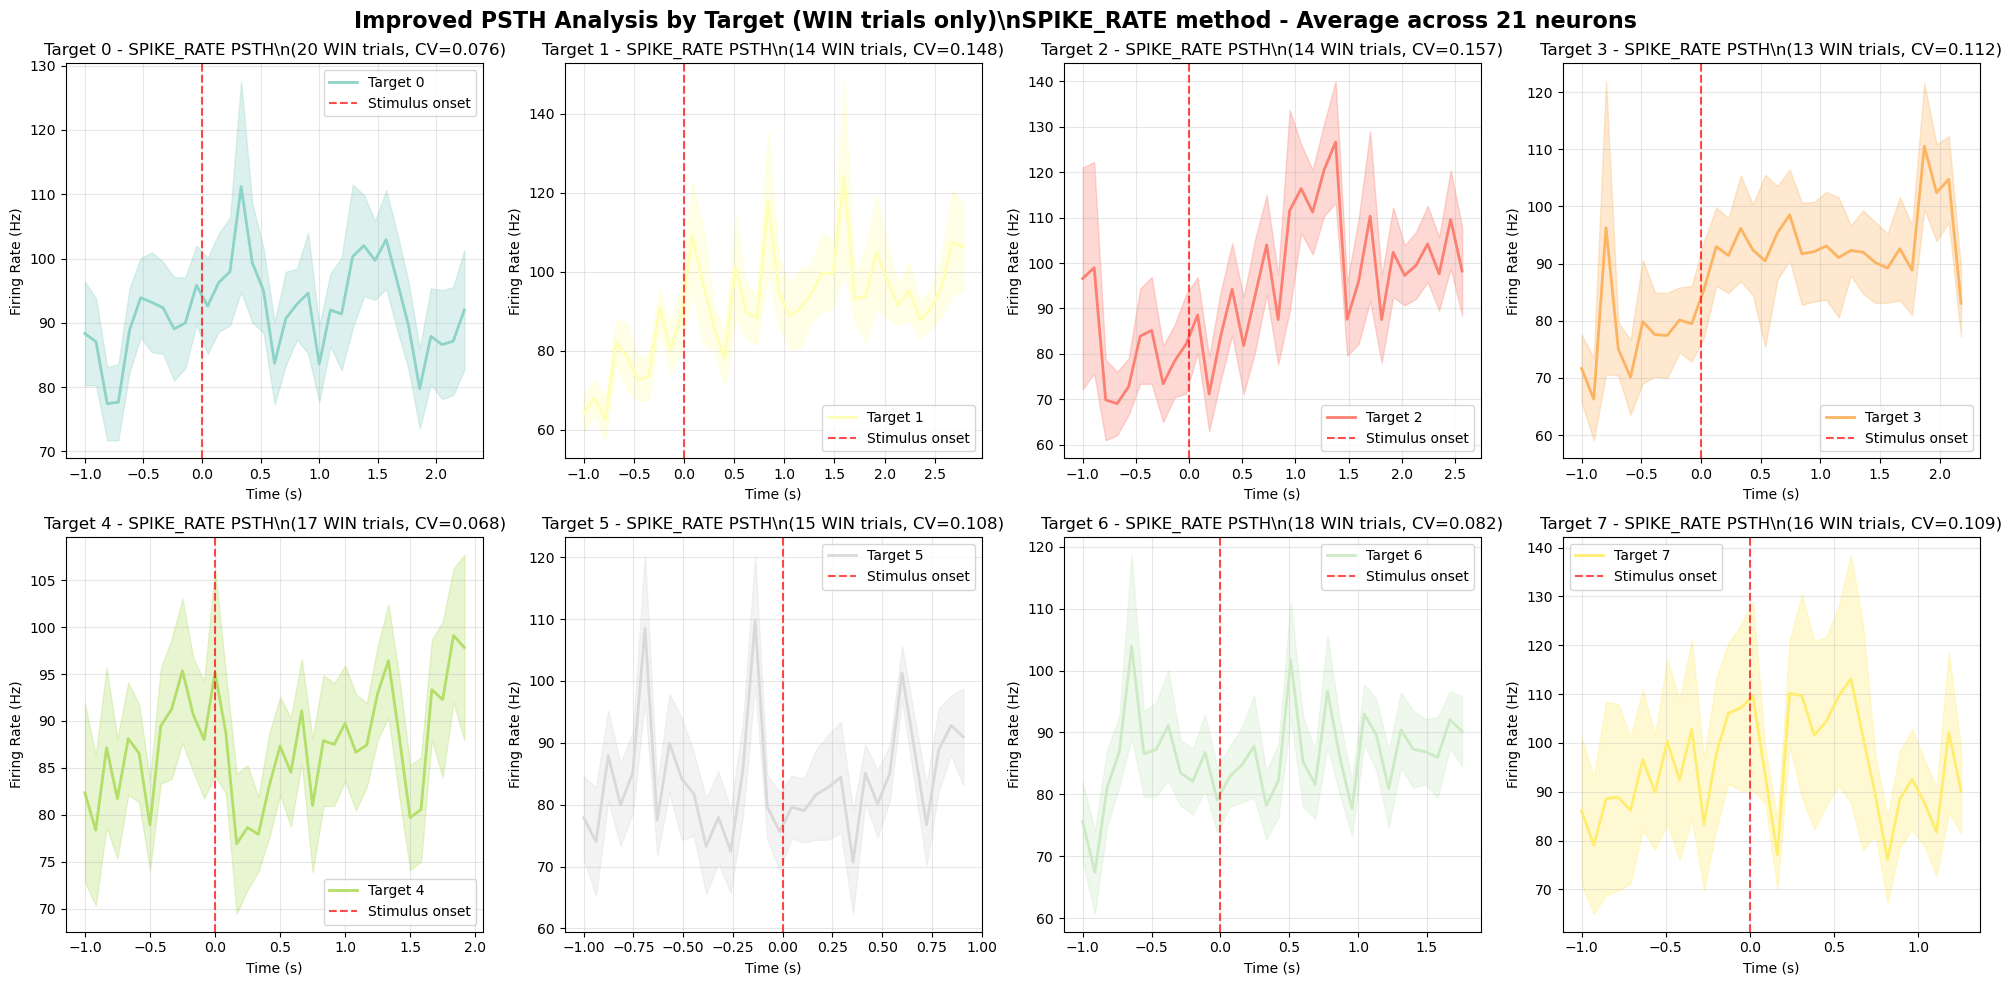

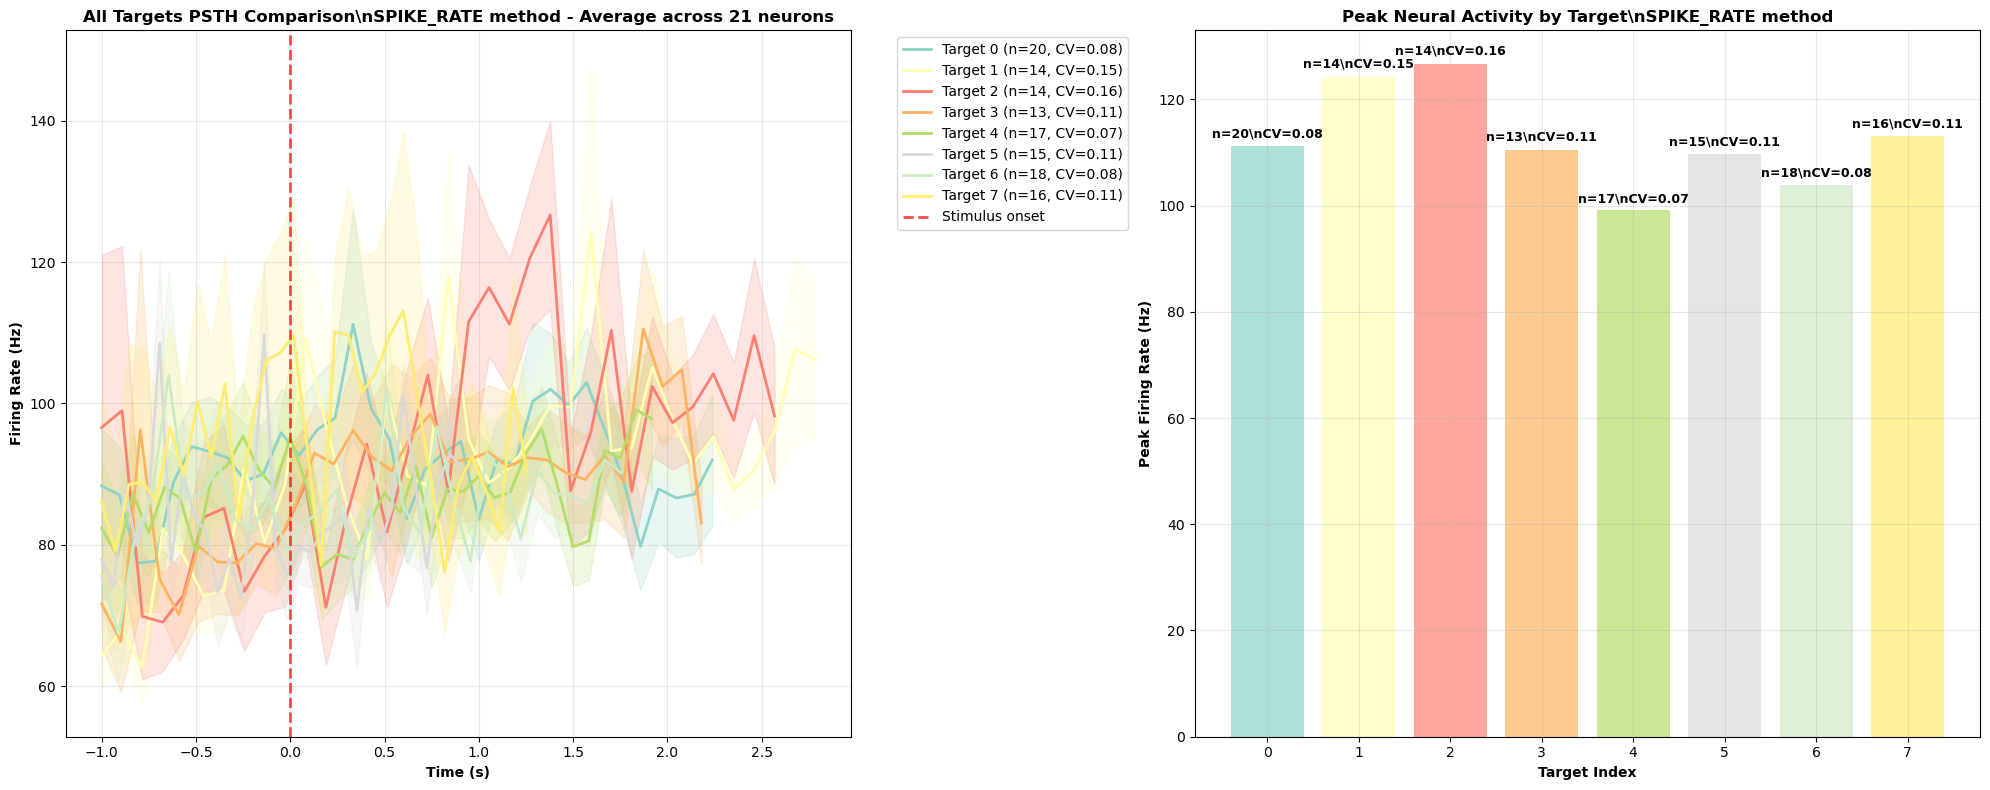

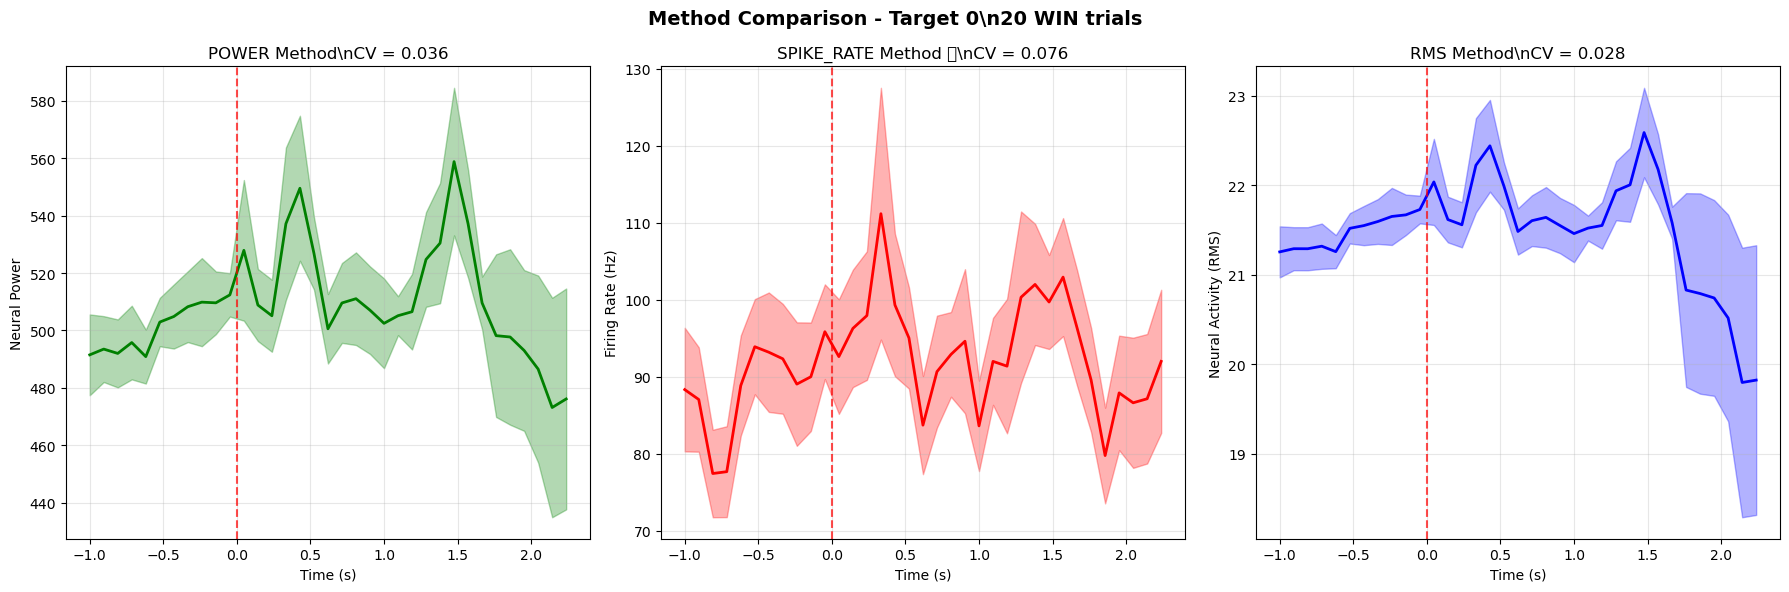

\n📊 IMPROVED PSTH ANALYSIS SUMMARY
🏆 Best method: SPIKE_RATE
📊 Total WIN trials analyzed: 127
🎯 Targets analyzed: 8
🧠 Neurons averaged: 21
⏱️ Time window: -1.0s to +3.0s
📏 Bin size: 50 ms
🔧 Filtering: 300-3000 Hz bandpass
\n🎯 Target-wise Statistics (SPIKE_RATE method):
   Target 0: 20 trials
     Peak activity: 111.190 at 0.33s
     Baseline activity: 85.540
     Peak/baseline ratio: 1.30
     Coefficient of variation: 0.076

   Target 1: 14 trials
     Peak activity: 124.218 at 1.59s
     Baseline activity: 71.156
     Peak/baseline ratio: 1.75
     Coefficient of variation: 0.148

   Target 2: 14 trials
     Peak activity: 126.667 at 1.38s
     Baseline activity: 81.456
     Peak/baseline ratio: 1.56
     Coefficient of variation: 0.157

   Target 3: 13 trials
     Peak activity: 110.549 at 1.87s
     Baseline activity: 75.883
     Peak/baseline ratio: 1.46
     Coefficient of variation: 0.112

   Target 4: 17 trials
     Peak activity: 99.104 at 1.83s
     Baseline activity: 84.052


In [10]:
# FINAL IMPROVED PSTH PLOTS
print("📊 Creating final improved PSTH plots...")

if len(improved_target_psths) > 0:
    # Create improved plots using the best method
    n_targets = len(improved_target_psths)
    n_cols = 4
    n_rows = (n_targets + n_cols - 1) // n_cols
    
    # Plot 1: Individual target PSTHs using best method
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    if n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    colors = plt.cm.Set3(np.linspace(0, 1, 8))
    
    plot_idx = 0
    for target_idx in sorted(improved_target_psths.keys()):
        if best_method not in improved_target_psths[target_idx]:
            continue
            
        row = plot_idx // n_cols
        col = plot_idx % n_cols
        ax = axes[row, col]
        
        data = improved_target_psths[target_idx][best_method]
        
        # Plot PSTH with error bars
        ax.plot(data['time'], data['psth'], color=colors[target_idx], linewidth=2, 
                label=f'Target {target_idx}')
        ax.fill_between(data['time'], 
                        data['psth'] - data['sem'], 
                        data['psth'] + data['sem'], 
                        alpha=0.3, color=colors[target_idx])
        
        # Add vertical line at stimulus onset
        ax.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Stimulus onset')
        
        # Formatting
        ax.set_xlabel('Time (s)')
        if best_method == 'spike_rate':
            ax.set_ylabel('Firing Rate (Hz)')
        elif best_method == 'power':
            ax.set_ylabel('Neural Power')
        else:
            ax.set_ylabel('Neural Activity (RMS)')
            
        ax.set_title(f'Target {target_idx} - {best_method.upper()} PSTH\\n({data["n_trials"]} WIN trials, CV={data["cv"]:.3f})')
        ax.grid(True, alpha=0.3)
        ax.legend()
        
        plot_idx += 1
    
    # Hide unused subplots
    for i in range(plot_idx, n_rows * n_cols):
        row = i // n_cols
        col = i % n_cols
        axes[row, col].set_visible(False)
    
    plt.suptitle(f'Improved PSTH Analysis by Target (WIN trials only)\\n{best_method.upper()} method - Average across 21 neurons', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Plot 2: Comparison across all targets
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # All PSTHs overlaid
    max_activity = 0
    for target_idx in sorted(improved_target_psths.keys()):
        if best_method not in improved_target_psths[target_idx]:
            continue
            
        data = improved_target_psths[target_idx][best_method]
        ax1.plot(data['time'], data['psth'], color=colors[target_idx], linewidth=2, 
                 label=f'Target {target_idx} (n={data["n_trials"]}, CV={data["cv"]:.2f})')
        ax1.fill_between(data['time'], 
                         data['psth'] - data['sem'], 
                         data['psth'] + data['sem'], 
                         alpha=0.2, color=colors[target_idx])
        max_activity = max(max_activity, np.max(data['psth']))
    
    ax1.axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Stimulus onset')
    ax1.set_xlabel('Time (s)', fontweight='bold')
    if best_method == 'spike_rate':
        ax1.set_ylabel('Firing Rate (Hz)', fontweight='bold')
    elif best_method == 'power':
        ax1.set_ylabel('Neural Power', fontweight='bold')
    else:
        ax1.set_ylabel('Neural Activity (RMS)', fontweight='bold')
        
    ax1.set_title(f'All Targets PSTH Comparison\\n{best_method.upper()} method - Average across 21 neurons', fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Peak activity comparison
    target_indices = sorted([t for t in improved_target_psths.keys() if best_method in improved_target_psths[t]])
    peak_activities = []
    peak_times = []
    n_trials = []
    cvs = []
    
    for target_idx in target_indices:
        data = improved_target_psths[target_idx][best_method]
        peak_idx = np.argmax(data['psth'])
        peak_activities.append(data['psth'][peak_idx])
        peak_times.append(data['time'][peak_idx])
        n_trials.append(data['n_trials'])
        cvs.append(data['cv'])
    
    bars = ax2.bar(target_indices, peak_activities, color=[colors[i] for i in target_indices], alpha=0.7)
    ax2.set_xlabel('Target Index', fontweight='bold')
    if best_method == 'spike_rate':
        ax2.set_ylabel('Peak Firing Rate (Hz)', fontweight='bold')
    elif best_method == 'power':
        ax2.set_ylabel('Peak Neural Power', fontweight='bold')
    else:
        ax2.set_ylabel('Peak Neural Activity', fontweight='bold')
        
    ax2.set_title(f'Peak Neural Activity by Target\\n{best_method.upper()} method', fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # Add trial count and CV labels on bars
    for bar, n_trial, cv in zip(bars, n_trials, cvs):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01, 
                 f'n={n_trial}\\nCV={cv:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Plot 3: Method comparison for one target
    if len(improved_target_psths) > 0:
        demo_target = sorted(improved_target_psths.keys())[0]
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        for i, method in enumerate(methods_to_try):
            if method in improved_target_psths[demo_target]:
                data = improved_target_psths[demo_target][method]
                
                axes[i].plot(data['time'], data['psth'], linewidth=2, color=['green', 'red', 'blue'][i])
                axes[i].fill_between(data['time'], 
                                   data['psth'] - data['sem'], 
                                   data['psth'] + data['sem'], 
                                   alpha=0.3, color=['green', 'red', 'blue'][i])
                axes[i].axvline(x=0, color='red', linestyle='--', alpha=0.7)
                
                axes[i].set_xlabel('Time (s)')
                if method == 'spike_rate':
                    axes[i].set_ylabel('Firing Rate (Hz)')
                elif method == 'power':
                    axes[i].set_ylabel('Neural Power')
                else:
                    axes[i].set_ylabel('Neural Activity (RMS)')
                    
                axes[i].set_title(f'{method.upper()} Method\\nCV = {data["cv"]:.3f}')
                axes[i].grid(True, alpha=0.3)
                
                if method == best_method:
                    axes[i].set_title(f'{method.upper()} Method ⭐\\nCV = {data["cv"]:.3f}')
        
        plt.suptitle(f'Method Comparison - Target {demo_target}\\n{improved_target_psths[demo_target][best_method]["n_trials"]} WIN trials', 
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    # Summary statistics
    print(f"\\n📊 IMPROVED PSTH ANALYSIS SUMMARY")
    print("=" * 60)
    
    total_trials = sum(improved_target_psths[t][best_method]['n_trials'] 
                      for t in improved_target_psths.keys() 
                      if best_method in improved_target_psths[t])
    
    print(f"🏆 Best method: {best_method.upper()}")
    print(f"📊 Total WIN trials analyzed: {total_trials}")
    print(f"🎯 Targets analyzed: {len([t for t in improved_target_psths.keys() if best_method in improved_target_psths[t]])}")
    print(f"🧠 Neurons averaged: {len(SPIKE_CHANNELS)}")
    print(f"⏱️ Time window: -{PRE_STIMULUS_TIME}s to +{POST_STIMULUS_TIME}s")
    print(f"📏 Bin size: {BIN_SIZE*1000:.0f} ms")
    print(f"🔧 Filtering: 300-3000 Hz bandpass")
    
    print(f"\\n🎯 Target-wise Statistics ({best_method.upper()} method):")
    for target_idx in sorted(improved_target_psths.keys()):
        if best_method not in improved_target_psths[target_idx]:
            continue
            
        data = improved_target_psths[target_idx][best_method]
        peak_idx = np.argmax(data['psth'])
        peak_activity = data['psth'][peak_idx]
        peak_time = data['time'][peak_idx]
        baseline_activity = np.mean(data['psth'][data['time'] < -0.5])
        
        print(f"   Target {target_idx}: {data['n_trials']} trials")
        print(f"     Peak activity: {peak_activity:.3f} at {peak_time:.2f}s")
        print(f"     Baseline activity: {baseline_activity:.3f}")
        if baseline_activity > 0:
            print(f"     Peak/baseline ratio: {peak_activity/baseline_activity:.2f}")
        print(f"     Coefficient of variation: {data['cv']:.3f}")
        print()
        
    print("✅ Improved analysis complete!")
    
else:
    print("❌ No improved target PSTHs computed. Please check the debug output above.")
